In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [22]:
df = pd.read_csv("Train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [23]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


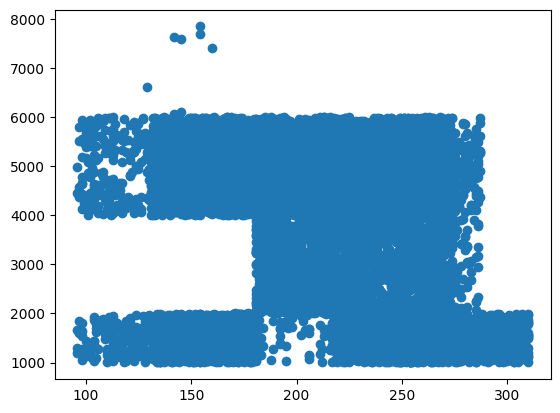

In [24]:
plt.scatter(df['Cost_of_the_Product'],df['Weight_in_gms'])

In [25]:
cluster_df = df[['Cost_of_the_Product','Weight_in_gms']].copy()

cluster_df.head()

,Cost_of_the_Product,Weight_in_gms
0,177,1233
1,216,3088
2,183,3374
3,176,1177
4,184,2484


In [26]:
km=KMeans(n_clusters=3,random_state=42)
predicted= km.fit_predict(cluster_df)
cluster_df['cluster']=predicted
cluster_df.head()

,Cost_of_the_Product,Weight_in_gms,cluster
0,177,1233,1
1,216,3088,2
2,183,3374,2
3,176,1177,1
4,184,2484,1


In [37]:
print("Cluster Centers:\n")
print(km.cluster_centers_)

Cluster Centers:

[[ 202.74066336 5345.00835727]
 [ 217.43746886 1671.99576482]
 [ 210.03390368 4053.58745247]]


Text(0, 0.5, 'cost of the product')

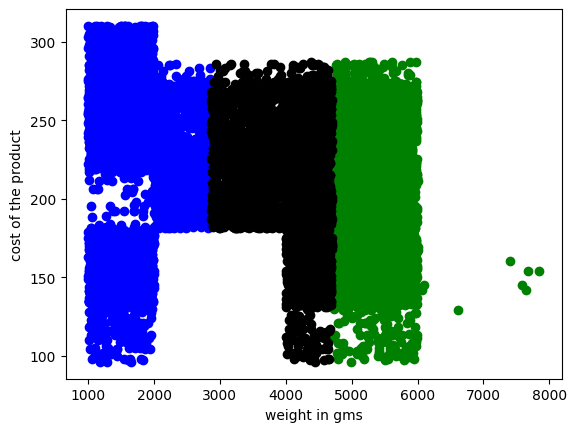

In [27]:
df1=cluster_df[cluster_df.cluster==0]
df2=cluster_df[cluster_df.cluster==1]
df3=cluster_df[cluster_df.cluster==2]
plt.scatter(df1.Weight_in_gms,df1['Cost_of_the_Product'],color='green')
plt.scatter(df2.Weight_in_gms,df2['Cost_of_the_Product'],color='blue')
plt.scatter(df3.Weight_in_gms,df3['Cost_of_the_Product'],color='black')
plt.xlabel('weight in gms')
plt.ylabel('cost of the product')


In [28]:

cluster_df['Cost_log'] = np.log1p(cluster_df['Cost_of_the_Product'])
cluster_df['Weight_log'] = np.log1p(cluster_df['Weight_in_gms'])

cluster_df[['Cost_log','Weight_log']].head()

,Cost_log,Weight_log
0,5.181784,7.118016
1,5.379897,8.035603
2,5.214936,8.124151
3,5.176150,7.071573
4,5.220356,7.818028


In [29]:
scaler = StandardScaler()

X = scaler.fit_transform(cluster_df[['Cost_log','Weight_log']])

In [38]:
kmeans = KMeans(
        n_clusters=3,
        random_state=42,
)

clusters = kmeans.fit_predict(X)

cluster_df['Cluster(scaled)'] = clusters

cluster_df.head(10)

,Cost_of_the_Product,Weight_in_gms,cluster,Cost_log,Weight_log,Cluster(scaled)
0,177,1233,1,5.181784,7.118016,1
1,216,3088,2,5.379897,8.035603,0
2,183,3374,2,5.214936,8.124151,2
3,176,1177,1,5.176150,7.071573,1
4,184,2484,1,5.220356,7.818028,2
5,162,1417,1,5.093750,7.257003,2
6,250,2371,1,5.525453,7.771489,1
7,233,2804,1,5.455321,7.939159,0
8,150,1861,1,5.017280,7.529406,2
9,164,1187,1,5.105945,7.080026,2


Text(0, 0.5, 'cost_log')

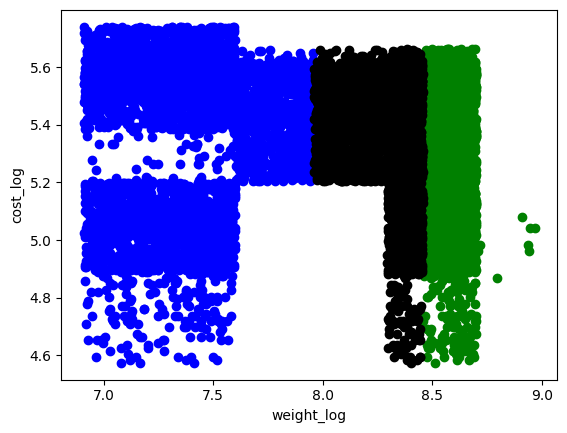

In [39]:
df1=cluster_df[cluster_df.cluster==0]
df2=cluster_df[cluster_df.cluster==1]
df3=cluster_df[cluster_df.cluster==2]
plt.scatter(df1.Weight_log,df1['Cost_log'],color='green')
plt.scatter(df2.Weight_log,df2['Cost_log'],color='blue')
plt.scatter(df3.Weight_log,df3['Cost_log'],color='black')
plt.xlabel('weight_log')
plt.ylabel('cost_log')


In [40]:
print("Cluster Centers:\n")
print(kmeans.cluster_centers_)

Cluster Centers:

[[ 0.34952666  0.66296906]
 [ 0.83869348 -1.21787308]
 [-1.29965458 -0.14884346]]


In [41]:
for i in range(3):
    print("\nCluster", i)
    print(cluster_df[cluster_df['Cluster(scaled)']==i].describe())


Cluster 0
       Cost_of_the_Product  Weight_in_gms      cluster     Cost_log  \
count          5354.000000    5354.000000  5354.000000  5354.000000   
mean            224.757938    4680.582929     0.922488     5.410237   
std              30.388899     846.352789     0.985495     0.136573   
min             160.000000    2470.000000     0.000000     5.081404   
25%             199.000000    4129.000000     0.000000     5.298317   
50%             225.000000    4758.000000     0.000000     5.420535   
75%             250.000000    5371.000000     2.000000     5.525453   
max             287.000000    7401.000000     2.000000     5.662960   

        Weight_log  Cluster(scaled)  
count  5354.000000           5354.0  
mean      8.433337              0.0  
std       0.195395              0.0  
min       7.812378              0.0  
25%       8.326033              0.0  
50%       8.467793              0.0  
75%       8.588956              0.0  
max       8.909506              0.0  

Cluste

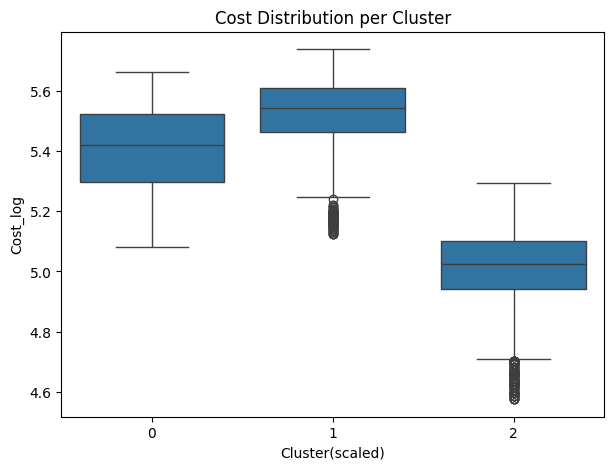

In [42]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Cluster(scaled)',
    y='Cost_log',
    data=cluster_df
)

plt.title("Cost Distribution per Cluster")
plt.show()

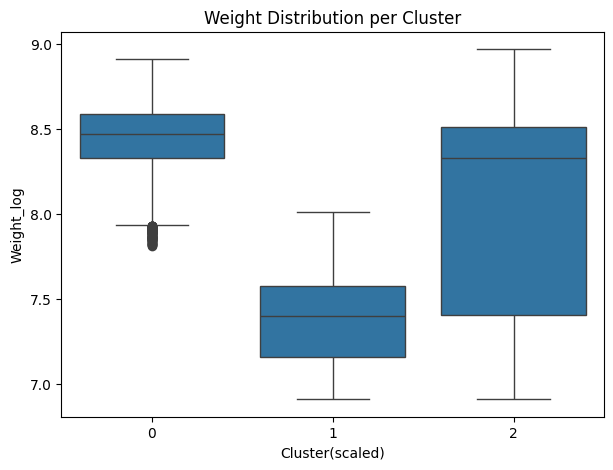

In [43]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Cluster(scaled)',
    y='Weight_log',
    data=cluster_df
)

plt.title("Weight Distribution per Cluster")
plt.show()